# 12 -- Model Validation, Comparison, Tuning & Persistence

**Pichle steps ka recap:** `11` ne default model ko test companies par ek baar evaluate kiya aur baselines ke saath compare kiya.

**Is notebook ka kaam (sab kuch SIRF train companies ki cross-validation se; test set par faisle ke liye nazar nahi):**
1. **Cross-validation:** kya `11` ka score ek "achhi qismat wali split" ka natija tha? 5-fold `GroupKFold` (company ke hisaab se) se dekhte hain.
2. **Model comparison:** HistGradientBoosting vs Logistic Regression vs baselines (majority, persistence).
3. **Hyperparameter tuning:** `RandomizedSearchCV` (train data par). Tuned params tabhi apnaye jayenge jab paired-CV mein behtari **noise (1 standard error) se bari** ho.
4. **Final model:** chune hue params se train companies par fit, **test companies par ek aakhri baar** evaluate, aur save (`models/`).
5. **Reload verification** aur `reports/final_results.md` (README ke liye tayyar table).

**Test companies se koi bhi faisla nahi hota:** model ya params ka intikhab sirf CV se hota hai.

## Working directory fix (zaroori)

In [11]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [12]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, balanced_accuracy_score

PROCESSED_DIR = Path("data/processed")
REPORTS_DIR = Path("reports")
MODEL_DIR = Path("models")
CV_CHARTS_DIR = REPORTS_DIR / "figures" / "model_validation_charts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CV_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "10_final_dataset.parquet"
TARGET = "target_next_quarter_health"
SEED = 42
N_FOLDS = 5

fs = json.load(open(REPORTS_DIR / "10_feature_selection_summary.json"))
FEATURES_NUM = fs["selected_ratio_growth_features"] + fs["selected_binary_context_features"]
SECTORS = fs["sector_categories"]
USE_SECTOR = fs["use_industry_sector"]

def build_feature_matrix(data):
    parts = [data[FEATURES_NUM].astype(float).reset_index(drop=True)]
    if USE_SECTOR:
        cat = pd.Categorical(data["industry_sector"], categories=SECTORS)
        parts.append(pd.get_dummies(cat, prefix="sector").astype(int).reset_index(drop=True))
    return pd.concat(parts, axis=1)

sns.set_style("whitegrid")
print(f"Features: {FEATURES_NUM}  |  sector dummies: {USE_SECTOR}")

Features: ['current_ratio', 'cash_ratio', 'debt_to_equity', 'debt_to_assets', 'operating_margin', 'roa', 'roe', 'asset_turnover', 'revenue_growth_qoq', 'netincome_growth_qoq', 'assets_growth_qoq', 'is_annual_filing', 'has_inventory']  |  sector dummies: True


## Load data + train/test (07 ki lock ki hui split)

In [13]:
df = pd.read_parquet(INPUT_PATH)
split = json.load(open(PROCESSED_DIR / "company_split.json"))
train_ciks, test_ciks = set(split["train_ciks"]), set(split["test_ciks"])

lab = df[df[TARGET].notna()].copy()
train = lab[lab["cik"].astype(str).isin(train_ciks)].reset_index(drop=True)
test = lab[lab["cik"].astype(str).isin(test_ciks)].reset_index(drop=True)
assert not (set(train["cik"]) & set(test["cik"])), "MASLA: company-overlap (leakage)!"
assert len(train) == split["n_train_rows"] and len(test) == split["n_test_rows"], "MASLA: split file aur dataset match nahi karte"

X_train, X_test = build_feature_matrix(train), build_feature_matrix(test)
y_train = (train[TARGET] == "Healthy").astype(int).values
y_test = (test[TARGET] == "Healthy").astype(int).values
groups_train = train["cik"].values
cur_train = train["eval_current_health_state"]

print(f"Train: {len(train)} rows / {train['cik'].nunique()} companies   |   Test (abhi tak touch nahi): {len(test)} rows")

Train: 27836 rows / 3922 companies   |   Test (abhi tak touch nahi): 7050 rows


---
# PART 1 -- 5-fold GroupKFold cross-validation: model comparison

**Kahani:** Ek hi split par score achhi/buri qismat ka bhi ho sakta hai. Cross-validation train companies ko 5 hisson mein baant kar har hissa ek baar "validation" banata hai (aur **ek company ki saari rows ek hi taraf** rehti hain). Isse score ke saath uska **fold-to-fold utar-chadhaav (noise)** bhi milta hai.

Chaar "khilari": **Majority**, **Persistence**, **Logistic Regression** (median imputation + missing-indicator + scaling), **HistGradientBoosting** (default).
Score: **ROC-AUC** (primary, class-imbalance se azad) aur **accuracy**.

=== 5-fold GroupKFold CV (train companies) ===
                    AUC_mean  AUC_std  ACC_mean  ACC_std
Majority              0.5000   0.0000    0.6482   0.0146
Persistence           0.8573   0.0069    0.8718   0.0068
LogisticRegression    0.8184   0.0013    0.7476   0.0070
HGB (default)         0.9427   0.0036    0.8857   0.0055

HGB - LogisticRegression:  AUC farq = +0.1243 (SE 0.0018) -> noise se bara   |   accuracy farq = +0.1381 (SE 0.0042) -> noise se bara

HGB - Persistence:  AUC farq = +0.0855 (SE 0.0017) -> noise se bara   |   accuracy farq = +0.0139 (SE 0.0014) -> noise se bara


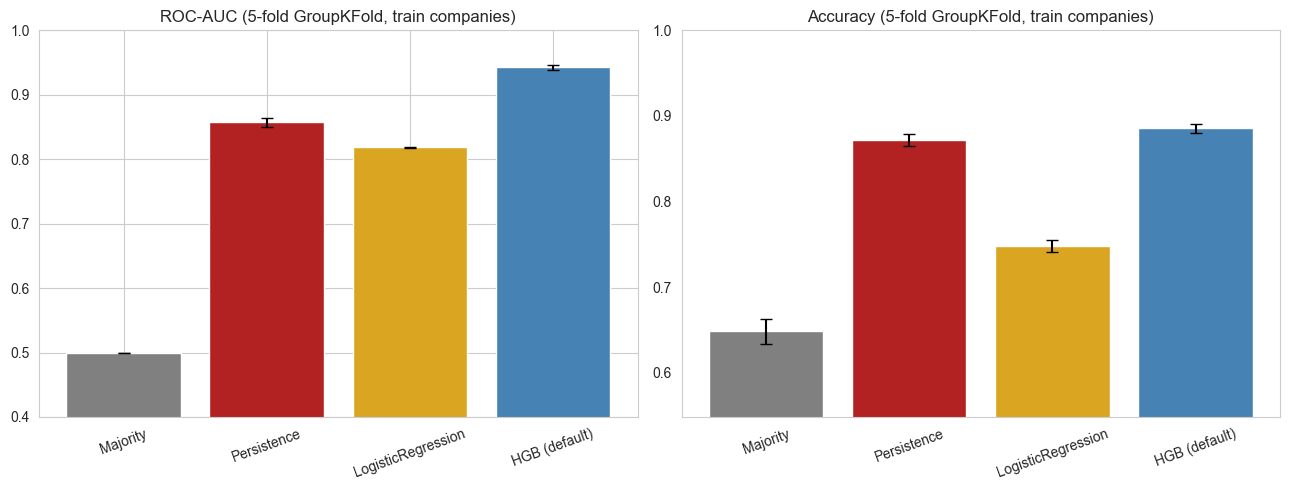

In [14]:
def make_logreg():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),   # missingness ka nishan bhi model ko milta hai
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
    ])

def make_hgb(**params):
    return HistGradientBoostingClassifier(random_state=SEED, **params)

folds = list(GroupKFold(n_splits=N_FOLDS).split(X_train, y_train, groups_train))
for k, (tr, va) in enumerate(folds):
    assert not (set(groups_train[tr]) & set(groups_train[va])), f"Fold {k}: company-overlap!"

cv = {name: {"auc": [], "acc": []} for name in ["Majority", "Persistence", "LogisticRegression", "HGB (default)"]}
for tr, va in folds:
    majority = int(y_train[tr].mean() >= 0.5)
    cur = cur_train.iloc[va]
    pred_p = np.where(cur.notna(), (cur == "Healthy").astype(int), majority)
    for name, pred in [("Majority", np.full(len(va), majority)), ("Persistence", pred_p)]:
        cv[name]["auc"].append(roc_auc_score(y_train[va], pred) if len(set(pred)) > 1 else 0.5)
        cv[name]["acc"].append(accuracy_score(y_train[va], pred))
    for name, model in [("LogisticRegression", make_logreg()), ("HGB (default)", make_hgb())]:
        model.fit(X_train.iloc[tr], y_train[tr])
        p = model.predict_proba(X_train.iloc[va])[:, 1]
        cv[name]["auc"].append(roc_auc_score(y_train[va], p))
        cv[name]["acc"].append(accuracy_score(y_train[va], (p >= 0.5).astype(int)))

cv_table = pd.DataFrame({name: {"AUC_mean": np.mean(v["auc"]), "AUC_std": np.std(v["auc"], ddof=1),
                                "ACC_mean": np.mean(v["acc"]), "ACC_std": np.std(v["acc"], ddof=1)} for name, v in cv.items()}).T
print(f"=== {N_FOLDS}-fold GroupKFold CV (train companies) ===")
print(cv_table.round(4).to_string())

def paired(a, b):
    d = np.array(a) - np.array(b)
    return d.mean(), d.std(ddof=1) / np.sqrt(len(d))

for label, (a, b) in {"HGB - LogisticRegression": ("HGB (default)", "LogisticRegression"),
                      "HGB - Persistence": ("HGB (default)", "Persistence")}.items():
    dm, dse = paired(cv[a]["auc"], cv[b]["auc"])
    dm_acc, dse_acc = paired(cv[a]["acc"], cv[b]["acc"])
    print(f"\n{label}:  AUC farq = {dm:+.4f} (SE {dse:.4f}) -> {'noise se bara' if dm > dse else 'noise ke andar'}"
          f"   |   accuracy farq = {dm_acc:+.4f} (SE {dse_acc:.4f}) -> {'noise se bara' if dm_acc > dse_acc else 'noise ke andar'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, key, title in zip(axes, ["auc", "acc"], ["ROC-AUC", "Accuracy"]):
    names = list(cv.keys())
    ax.bar(names, [np.mean(cv[n][key]) for n in names], yerr=[np.std(cv[n][key], ddof=1) for n in names],
           color=["gray", "firebrick", "goldenrod", "steelblue"], capsize=4)
    ax.set_title(f"{title} ({N_FOLDS}-fold GroupKFold, train companies)")
    ax.tick_params(axis="x", rotation=20)
    lo = min(np.mean(cv[n][key]) for n in names)
    ax.set_ylim(max(0, lo - 0.1), 1.0)
    
plt.tight_layout()
plt.grid(False)
plt.savefig(CV_CHARTS_DIR / "01_cv_model_comparison.png", dpi=120)
plt.show()

**Insight kaise padhein:** "noise se bara" ka matlab: farq itna hai ke fold-to-fold utar-chadhaav se samjhaya nahi ja sakta. Agar HGB, Logistic Regression se AUC mein noise se bara behtar hai, to yeh is baat ka saboot hai ke rishte **non-linear** hain
(seedhi line se nahi pakde ja sakte). Persistence se accuracy ka farq chhota ho sakta hai (dekhein `11`), lekin AUC ka farq dikhata hai ke model risk ko persistence se behtar **rank** karta hai.

---
# PART 2 -- Hyperparameter tuning (sirf train companies ki CV se)

**Kahani:** Model ke "knobs" (kitne trees, kitni gehrai, seekhne ki raftar...) alag alag combination mein aazmaye jate hain. `RandomizedSearchCV` poori grid ke bajaye random combinations aazmata hai (tez aur aksar kaafi).

**Ehtiyat:** search ka apna score (3-fold) optimistic ho sakta hai (best of many). Isliye tuned params ko **dobara wahi 5-fold folds** par default ke muqable mein aazmate hain aur **paired farq noise se bara ho tabhi** apnate hain.

Best params (search): {'min_samples_leaf': 100, 'max_iter': 100, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 0.1}
Search ka best 3-fold AUC: 0.9418   (optimistic ho sakta hai)

Default HGB (5-fold): AUC = 0.9427
Tuned   HGB (5-fold): AUC = 0.9428
Paired farq = +0.0001 (SE 0.0002)

FAISLA: DEFAULT params rakhe gaye (tuning ka farq noise ke andar, isliye behtari ka saboot nahi)


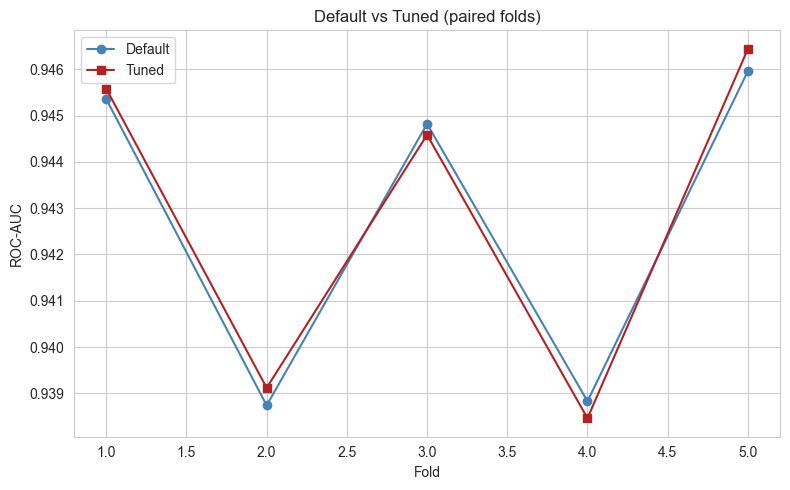

In [15]:
param_dist = {
    "max_iter": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "learning_rate": [0.05, 0.1, 0.2],
    "l2_regularization": [0, 0.1, 1.0],
    "min_samples_leaf": [20, 50, 100],
}
search = RandomizedSearchCV(
    make_hgb(), param_distributions=param_dist, n_iter=12, cv=GroupKFold(3),
    scoring="roc_auc", random_state=SEED, n_jobs=-1,
)
search.fit(X_train, y_train, groups=groups_train)
print(f"Best params (search): {search.best_params_}")
print(f"Search ka best 3-fold AUC: {search.best_score_:.4f}   (optimistic ho sakta hai)")

tuned_auc, tuned_acc = [], []
for tr, va in folds:
    m = make_hgb(**search.best_params_).fit(X_train.iloc[tr], y_train[tr])
    p = m.predict_proba(X_train.iloc[va])[:, 1]
    tuned_auc.append(roc_auc_score(y_train[va], p)); tuned_acc.append(accuracy_score(y_train[va], (p >= 0.5).astype(int)))

d_mean, d_se = paired(tuned_auc, cv["HGB (default)"]["auc"])
print(f"\nDefault HGB (5-fold): AUC = {np.mean(cv['HGB (default)']['auc']):.4f}")
print(f"Tuned   HGB (5-fold): AUC = {np.mean(tuned_auc):.4f}")
print(f"Paired farq = {d_mean:+.4f} (SE {d_se:.4f})")

use_tuned = d_mean > d_se
chosen_params = dict(search.best_params_) if use_tuned else {}
print(f"\nFAISLA: {'TUNED params apnaye gaye (farq noise se bara)' if use_tuned else 'DEFAULT params rakhe gaye (tuning ka farq noise ke andar, isliye behtari ka saboot nahi)'}")

fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(1, N_FOLDS + 1)
ax.plot(xs, cv["HGB (default)"]["auc"], marker="o", label="Default", color="steelblue")
ax.plot(xs, tuned_auc, marker="s", label="Tuned", color="firebrick")
ax.set_xlabel("Fold"); ax.set_ylabel("ROC-AUC"); ax.set_title("Default vs Tuned (paired folds)"); ax.legend()
plt.tight_layout()
plt.savefig(CV_CHARTS_DIR / "02_default_vs_tuned.png", dpi=120)
plt.show()

**Insight kaise padhein:** Agar tuning ka farq noise ke andar ho, to iska matlab default parameters pehle se kaafi achhe the (yeh aam taur par hota hai, khaaskar jab data kam ho ya signal kamzor). Tab **simpler, default model** hi rakha jata hai.

---
# PART 3 -- Final model: train companies par fit, test companies par ek aakhri evaluate

**Kahani:** Ab tak test companies ko sirf `11` ne ek default model ke liye dekha tha (aur us se koi faisla nahi hua). Ab jo model CV se chuna gaya, usay train par fit karke test par ek aakhri baar dekhte hain.
Yeh **wahi model** hai jo save hoga, is liye reported test score aur saved model mein koi farq nahi.

In [16]:
final_model = make_hgb(**chosen_params).fit(X_train, y_train)
p_test = final_model.predict_proba(X_test)[:, 1]
pred_test = (p_test >= 0.5).astype(int)

majority_label = int(y_train.mean() >= 0.5)
cur_test = test["eval_current_health_state"]
pred_persist = np.where(cur_test.notna(), (cur_test == "Healthy").astype(int), majority_label)

final_test = {
    "accuracy": accuracy_score(y_test, pred_test), "balanced_accuracy": balanced_accuracy_score(y_test, pred_test),
    "roc_auc": roc_auc_score(y_test, p_test),
}
persist_test = {"accuracy": accuracy_score(y_test, pred_persist), "roc_auc": roc_auc_score(y_test, pred_persist)}
majority_test = {"accuracy": accuracy_score(y_test, np.full(len(y_test), majority_label))}

s11 = json.load(open(REPORTS_DIR / "11_modeling_summary.json"))
print(f"Final model test:  accuracy = {final_test['accuracy']:.4f}   ROC-AUC = {final_test['roc_auc']:.4f}   balanced acc = {final_test['balanced_accuracy']:.4f}")
print(f"Persistence test:  accuracy = {persist_test['accuracy']:.4f}   ROC-AUC = {persist_test['roc_auc']:.4f}")
print(f"Majority   test:   accuracy = {majority_test['accuracy']:.4f}")
print(f"(11 ka default model: accuracy = {s11['test']['model']['accuracy']:.4f}, ROC-AUC = {s11['test']['model']['roc_auc']:.4f})")
print(f"\nParams: {final_model.get_params()['max_iter']} trees max, {'DEFAULT' if not chosen_params else 'TUNED'} -> {chosen_params if chosen_params else '{}'}")

Final model test:  accuracy = 0.8762   ROC-AUC = 0.9367   balanced acc = 0.8653
Persistence test:  accuracy = 0.8600   ROC-AUC = 0.8449
Majority   test:   accuracy = 0.6532
(11 ka default model: accuracy = 0.8762, ROC-AUC = 0.9367)

Params: 100 trees max, DEFAULT -> {}


## Model + zaroori files save karna

In [17]:
joblib.dump(final_model, MODEL_DIR / "health_classifier.joblib")

feature_config = {
    "target": TARGET,
    "classes": {"0": "At-Risk", "1": "Healthy"},
    "positive_class_probability": "predict_proba[:, 1] = P(Healthy)",
    "threshold": 0.5,
    "features_numeric_binary": FEATURES_NUM,
    "use_industry_sector": bool(USE_SECTOR),
    "sector_categories": SECTORS,
    "feature_columns": list(X_train.columns),
    "hyperparameters": chosen_params,
    "trained_on": {"n_rows": int(len(train)), "n_companies": int(train["cik"].nunique()),
                   "note": "Sirf train companies (test companies model ne kabhi nahi dekhin)."},
    "versions": {"python": sys.version.split()[0], "scikit_learn": sklearn.__version__},
}
with open(MODEL_DIR / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

# 08 ki winsorization bounds: naye data par bilkul wahi clipping lagegi jo training mein lagi (13 use karta hai)
bounds = json.load(open(PROCESSED_DIR / "08_winsorization_bounds.json"))
with open(MODEL_DIR / "winsorization_bounds.json", "w") as f:
    json.dump(bounds, f, indent=2)

print("Saved artifacts:")
for f in sorted(MODEL_DIR.glob("*")):
    print(f"  {f}  ({f.stat().st_size / 1024:.1f} KB)")

Saved artifacts:
  models\feature_config.json  (1.6 KB)
  models\health_classifier.joblib  (221.9 KB)
  models\winsorization_bounds.json  (1.2 KB)


## Reload-Verification (saboot ke saved model genuinely kaam karta hai)

Model save karna aur uska sahi kaam karna do alag cheezein hain. Reload karke dekhte hain: kya same rows par same probabilities aati hain, aur kya config ke feature columns training ke columns se bilkul milte hain?

In [18]:
reloaded = joblib.load(MODEL_DIR / "health_classifier.joblib")
cfg = json.load(open(MODEL_DIR / "feature_config.json"))

assert cfg["feature_columns"] == list(X_train.columns), "MASLA: config ke feature columns training se alag hain"
assert list(reloaded.classes_) == [0, 1]

sample = X_test.head(200)
p_orig = final_model.predict_proba(sample)[:, 1]
p_reload = reloaded.predict_proba(sample[cfg["feature_columns"]])[:, 1]
assert np.allclose(p_orig, p_reload), "MASLA: reloaded model ki predictions match nahi karti!"
print("[OK] Reloaded model ki predictions original se bilkul barabar (200 test rows).")
print("[OK] feature_config.json ke columns training ke columns se bilkul milte hain.")

[OK] Reloaded model ki predictions original se bilkul barabar (200 test rows).
[OK] feature_config.json ke columns training ke columns se bilkul milte hain.


---
# PART 4 -- Summary + README ke liye tayyar results table

`reports/final_results.md` mein woh numbers hain jo aap ke apne run se aaye: **README mein yehi table paste karein** (koi purana/andaze wala number nahi).

In [19]:
summary = {
    "generated_by": "12_model_validation_and_persistence.ipynb",
    "cv": {"folds": N_FOLDS, "scheme": "GroupKFold by company (train companies only)",
           "table": {n: {k: round(float(v), 4) for k, v in row.items()} for n, row in cv_table.iterrows()}},
    "tuning": {"best_params_search": {k: (None if v is None else v) for k, v in search.best_params_.items()},
               "search_best_3fold_auc": round(float(search.best_score_), 4),
               "tuned_5fold_auc": round(float(np.mean(tuned_auc)), 4),
               "default_5fold_auc": round(float(np.mean(cv["HGB (default)"]["auc"])), 4),
               "paired_diff": round(float(d_mean), 4), "paired_se": round(float(d_se), 4),
               "adopted_tuned_params": bool(use_tuned)},
    "final_model_test": {k: round(float(v), 4) for k, v in final_test.items()},
    "persistence_test": {k: round(float(v), 4) for k, v in persist_test.items()},
    "majority_test": {k: round(float(v), 4) for k, v in majority_test.items()},
    "artifacts": sorted(f.name for f in MODEL_DIR.glob("*")),
}
with open(REPORTS_DIR / "12_model_validation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("[SAVED] reports/12_model_validation_summary.json")

ew, rc = s11["early_warning_currently_healthy"], s11["recovery_currently_atrisk"]
lines = [
    "## Results (auto-generated by `12_model_validation_and_persistence.ipynb`)",
    "",
    f"**Data:** {s11['n_train_companies'] + s11['n_test_companies']:,} companies; train = {s11['n_train_companies']:,} companies / {s11['n_train_rows']:,} rows; "
    f"**test (locked in `07`) = {s11['n_test_companies']:,} companies / {s11['n_test_rows']:,} rows**. Target: next-quarter `Healthy` vs `At-Risk` (Healthy share {s11['healthy_share_test']:.1%} in test).",
    "",
    "### Test-set performance (company-grouped hold-out, evaluated once)",
    "",
    "| Predictor | Accuracy | ROC-AUC |",
    "|---|---|---|",
    f"| Majority class (always At-Risk) | {majority_test['accuracy']:.1%} | 0.500 |",
    f"| Persistence (\"stays the same\") | {persist_test['accuracy']:.1%} | {persist_test['roc_auc']:.3f} |",
    f"| **Final model (HistGradientBoosting)** | **{final_test['accuracy']:.1%}** | **{final_test['roc_auc']:.3f}** |",
    "",
    f"### {N_FOLDS}-fold GroupKFold cross-validation (train companies)",
    "",
    "| Model | ROC-AUC (mean ± std) | Accuracy (mean ± std) |",
    "|---|---|---|",
] + [f"| {n} | {r['AUC_mean']:.3f} ± {r['AUC_std']:.3f} | {r['ACC_mean']:.3f} ± {r['ACC_std']:.3f} |" for n, r in cv_table.iterrows()] + [
    "",
    "### Where the model adds value beyond \"stays the same\"",
    "",
    f"- Status changes at T+1 in **{s11['status_change']['n_changed_rows']:,}** test rows; the model gets **{s11['status_change']['model_acc_on_changed']:.1%}** of these right (persistence: 0%).",
    f"- **Early warning** (currently Healthy, {ew['n_rows']:,} rows, {ew['base_rate']:.1%} actually fall to At-Risk): the model's riskiest 10% contain **{ew['top_decile_rate']:.1%}** fallers "
    f"(**{ew['lift']:.2f}x lift**), capturing {ew['capture']:.1%} of all fallers; within-group AUC = {ew['auc']:.3f}.",
    f"- **Recovery** (currently At-Risk, {rc['n_rows']:,} rows, {rc['base_rate']:.1%} recover): top-10% precision **{rc['top_decile_rate']:.1%}** ({rc['lift']:.2f}x lift); within-group AUC = {rc['auc']:.3f}.",
    f"- Probability calibration gap (10 bins): {s11['test']['calibration_gap']:.3f}; Brier = {s11['test']['brier']:.3f}.",
]
(REPORTS_DIR / "final_results.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("[SAVED] reports/final_results.md\n")
print("\n".join(lines))

[SAVED] reports/12_model_validation_summary.json
[SAVED] reports/final_results.md

## Results (auto-generated by `12_model_validation_and_persistence.ipynb`)

**Data:** 4,903 companies; train = 3,922 companies / 27,836 rows; **test (locked in `07`) = 981 companies / 7,050 rows**. Target: next-quarter `Healthy` vs `At-Risk` (Healthy share 34.7% in test).

### Test-set performance (company-grouped hold-out, evaluated once)

| Predictor | Accuracy | ROC-AUC |
|---|---|---|
| Majority class (always At-Risk) | 65.3% | 0.500 |
| Persistence ("stays the same") | 86.0% | 0.845 |
| **Final model (HistGradientBoosting)** | **87.6%** | **0.937** |

### 5-fold GroupKFold cross-validation (train companies)

| Model | ROC-AUC (mean ± std) | Accuracy (mean ± std) |
|---|---|---|
| Majority | 0.500 ± 0.000 | 0.648 ± 0.015 |
| Persistence | 0.857 ± 0.007 | 0.872 ± 0.007 |
| LogisticRegression | 0.818 ± 0.001 | 0.748 ± 0.007 |
| HGB (default) | 0.943 ± 0.004 | 0.886 ± 0.006 |

### Where the model adds v

## Sanity Checks

In [20]:
assert not (set(train["cik"]) & set(test["cik"]))
for f in ["health_classifier.joblib", "feature_config.json", "winsorization_bounds.json"]:
    assert (MODEL_DIR / f).exists(), f"MASLA: {f} save nahi hui"
assert not (MODEL_DIR / "growth_regressor.joblib").exists(), "MASLA: purana regression model models/ mein pada hai -- delete karein"
assert not (MODEL_DIR / "financial_profile_clusterer.joblib").exists(), "MASLA: purana clustering model models/ mein pada hai -- delete karein"
assert len(list(CV_CHARTS_DIR.glob("*.png"))) == 2
print("[OK] Zaroori artifacts maujood, purane regression/clustering models nahi.")
print("[OK] 2 charts bane.")
print("\n=== PROJECT COMPLETE: Raw SEC data -> Cleaned -> EDA -> Features -> Health target -> Selection -> Model -> CV -> Saved (models/) ===")

[OK] Zaroori artifacts maujood, purane regression/clustering models nahi.
[OK] 2 charts bane.

=== PROJECT COMPLETE: Raw SEC data -> Cleaned -> EDA -> Features -> Health target -> Selection -> Model -> CV -> Saved (models/) ===
